# Exercise 30.2b solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Model parameters
R_T = 1
k_0_on = 0
k_0_off = 100
k_Ca_on = 120
k_Ca_off = 50
Ca_50 = k_Ca_off / k_Ca_on

f_0 = 50
f_prime_0 = 400
h = 8
h_prime = 6
g = 4

u = 8
v = 2
w = 3

Ca = Ca_50 * 100


def rhs_cooperative(t, y, Ca, u, v, w):
    """Right-hand side of the cooperative Razumova model."""
    D, A_1, A_2 = y

    # Ca-dependent base rates
    k_u_on = k_0_on + (k_Ca_on - k_0_on) * Ca / (Ca_50 + Ca)
    k_u_off = k_0_off + (k_Ca_off - k_0_off) * Ca / (Ca_50 + Ca)

    # State subpopulations
    R_off = R_T - D - A_1 - A_2
    lambda_A2 = A_2 / R_T
    lambda_on = (D + A_1 + A_2) / R_T

    # XB-XB cooperativity (parameter v)
    f = f_0 * (1 + lambda_A2 * (np.exp(v - 1) - 1)) ** 2
    f_prime = f_prime_0 * (1 + lambda_A2 * (np.exp(-(v - 1)) - 1)) ** 2

    # RU-RU cooperativity (parameter u)
    k_w_on = k_u_on * (1 + lambda_on * (u - 1)) ** 2
    k_w_off = k_u_off * (u - lambda_on * (u - 1)) ** 2

    # XB-RU cooperativity (parameter w)
    k_on = k_w_on * (1 + lambda_A2 * (np.exp(w - 1) - 1)) ** 2
    k_off = k_w_off * (1 + lambda_A2 * (np.exp(-(w - 1)) - 1)) ** 2

    # ODEs
    dD_dt = k_on * R_off + f_prime * A_1 + g * A_2 - (k_off + f) * D
    dA1_dt = f * D + h_prime * A_2 - (f_prime + h) * A_1
    dA2_dt = h * A_1 - (h_prime + g) * A_2

    return [dD_dt, dA1_dt, dA2_dt]


# ----------------------------------------------

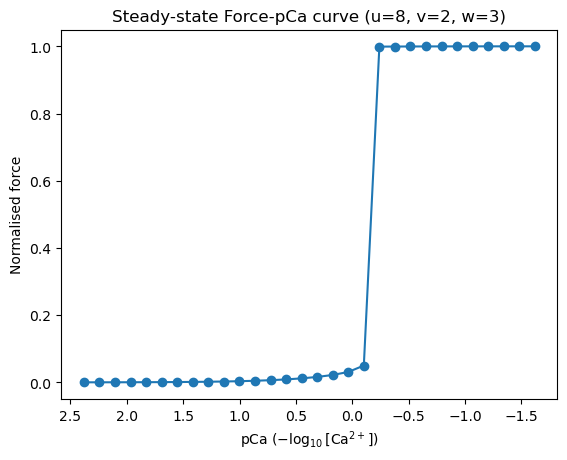

In [ ]:
Ca_values = np.logspace(-2, 2, 30) * Ca_50
steady_state_force = []

for Ca_val in Ca_values:
    sol = solve_ivp(
        rhs_cooperative,
        (0, 50),
        [0.01, 0.01, 0.01],
        method="LSODA",
        args=(Ca_val, u, v, w),
    )
    steady_state_force.append(sol.y[2, -1])

steady_state_force = np.array(steady_state_force)
pCa = -np.log10(Ca_values)

plt.plot(pCa, steady_state_force / steady_state_force.max(), "o-", color="C0")
plt.xlabel("pCa ($-\\log_{10}[\\mathrm{Ca}^{2+}]$)")
plt.ylabel("Normalised force")
plt.title(f"Steady-state Force-pCa curve (u={u}, v={v}, w={w})")
plt.gca().invert_xaxis()
plt.show()

1. Does the resulting force-pCa curve look sigmoidal? How does its steepness compare to the experimental data shown in the theory chapter?

Yes, with the default cooperativity parameters ($u=8$, $v=2$, $w=3$), the force-pCa curve is steep and sigmoidal, qualitatively matching the experimental cardiac muscle data. The Hill coefficient of the curve is approximately 3–5, which falls within the physiologically observed range (Hill coefficient ≈ 3–7 for cardiac muscle).

2. What is the approximate $\text{pCa}_{50}$ of your curve?

The $\text{pCa}_{50}$ (the pCa at which normalised force equals 0.5) is approximately 5.5–6.0 with the default parameters. This is consistent with typical experimental values for cardiac muscle, which range from about 5.5 to 6.2 depending on species and conditions.
